## Chebyshev 1: Transforms, Collocation, and Interpolation

In [6]:
import sys
import os
import math
import numpy as np
import scipy

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
%config InlineBackend.figure_format = 'retina'

import seaborn as sns

# SEABORN & MATPLOTLIBN CONFIGURATION
# seaborn styles (choose by changing index at end)
context=['paper', 'notebook', 'talk', 'poster'] [1]
palette=['deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind', 'hls', 'tab10'] [2]
style=['darkgrid', 'whitegrid', 'dark', 'white', 'ticks'] [4] 

# extra customizations
# https://matplotlib.org/stable/tutorials/introductory/customizing.html
# uncomment this to get list of all rc-params: 
#print(plt.rcParams.keys())
rc={"axes.grid":"false", #"true",
    "axes.grid.which": "major",
    "grid.color":'lightgrey',
    "grid.linewidth":0.6,
    'xtick.direction':'in',
    'xtick.top':True,
    'ytick.direction':'in',
    'ytick.right':True
    }

sns.set_theme(style=style,context=context, palette=palette,
              font_scale=1, rc=rc)
print(sys.version)
print("Seaborn version {}".format(sns.__version__))

3.8.16 (default, Jun 12 2023, 18:09:05) 
[GCC 11.2.0]
Seaborn version 0.12.2


In [1]:
sys.path.append("../Final")
import Chebyshev

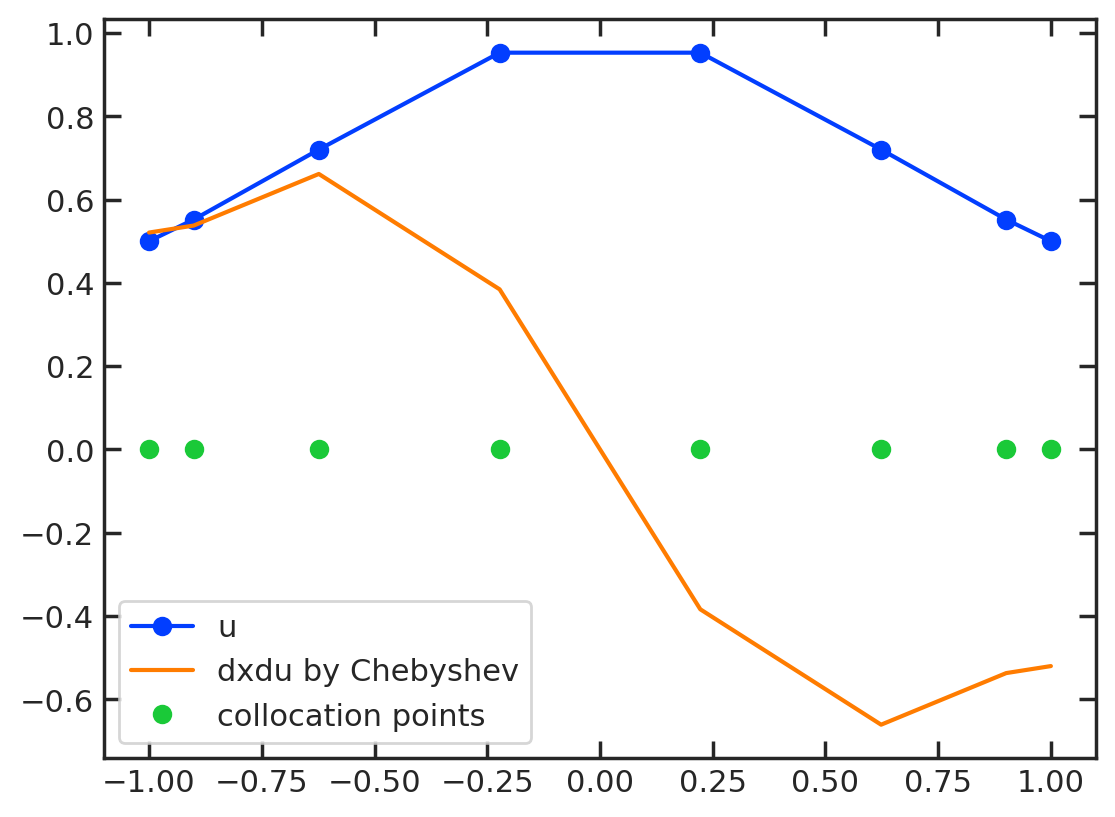

In [10]:
N = 8
x, ToSpec, ToPhys, D1, D2 = Chebyshev.ChebyshevHelpers(N)

# test:
u = 1.0 / (1.0 + x**2)

dudx_Cheby = D1 @ u

plt.plot(x, u, '-o', label="u")
plt.plot(x, dudx_Cheby, label="dxdu by Chebyshev")
plt.plot(x, 0 * x, "o", label="collocation points")
plt.legend()

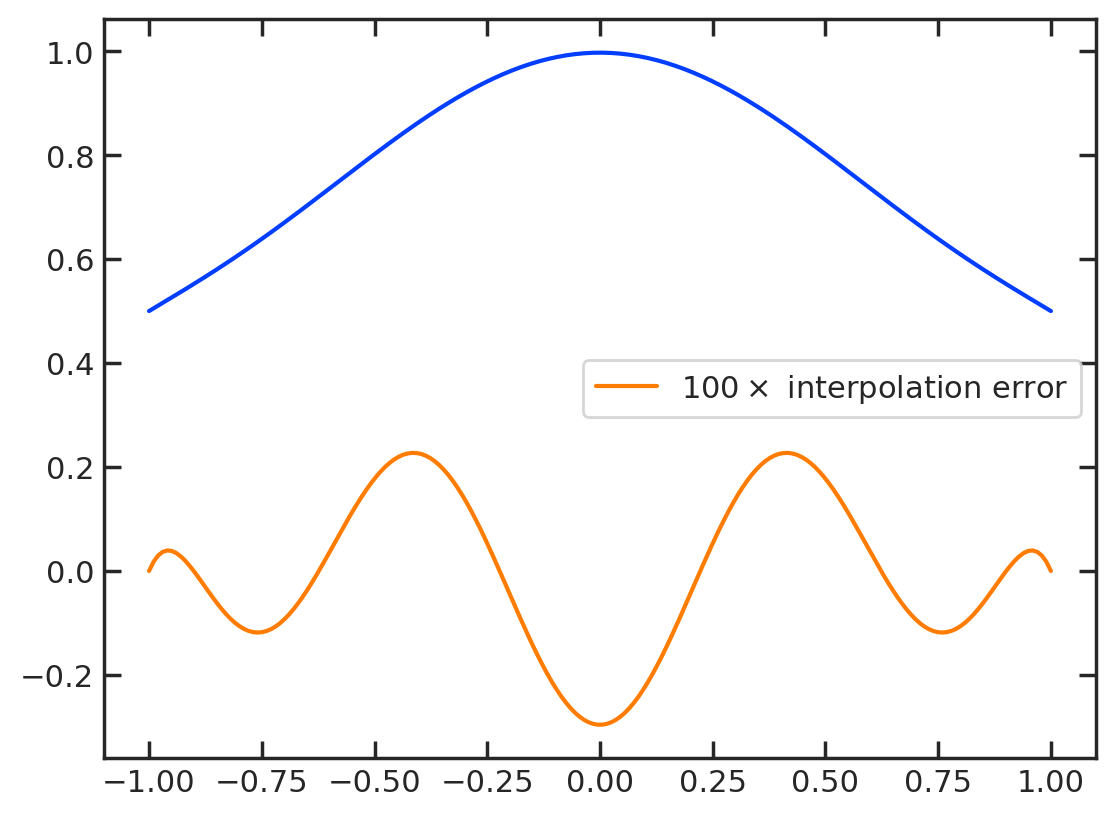

In [12]:
# interpolate functions, to see their full smoothness and glory
x_fine = np.linspace(-1, 1, num=200)
uspec = ToSpec @ u

u_interpolated = np.zeros(200)

for k, coef in enumerate(uspec):
    u_interpolated += coef * np.cos(k * np.arccos(x_fine))

plt.plot(x_fine, u_interpolated)
plt.plot(
    x_fine,
    100 * (u_interpolated - 1 / (1 + x_fine**2)),
    label="$100\\times$ interpolation error",
)
plt.legend()

In [22]:
uspec

array([ 7.07106781e-01, -7.63278329e-17, -2.42640687e-01,  1.00613962e-16,
        4.16305602e-02,  5.58580959e-16, -7.14267402e-03,  1.38777878e-16,
        1.22548391e-03, -3.74700271e-16, -2.10229458e-04,  5.55111512e-17,
        3.58928343e-05, -3.88578059e-16, -5.12754775e-06,  0.00000000e+00])